# 符号分类久期分析

## 分析背景

发现估算的久期普遍比实际久期低，需要探究原因。本分析的思路是：

1. 拉长时间窗口，获取更多观测点
2. 将观测点按基金收益率与指数综合收益率的符号关系分为三类：
   - **同正**：基金和指数都上涨
   - **同负**：基金和指数都下跌
   - **反向**：一正一负
3. 分别对三类数据做久期测算
4. 与Wind实际久期对比，分析哪种情况下测算更准确

## 标准流程参考

参考 `纯债基金久期测算.ipynb` 的标准流程

## 1. 导入模块

In [13]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 导入自定义模块
from data_preprocessing import FundDataPreprocessor
from fund_type_classifier import FundTypeClassifier
from wind_data_fetcher import WindDataFetcher
from bond_index_data import BondIndexDataProcessor
from duration_model import FundDurationCalculator
from data_cache import WindDataCache
from duration_sign_analysis import SignBasedDurationAnalyzer

print('模块导入成功')

模块导入成功


## 2. 初始化各模块

In [14]:
# 1. 数据预处理器
preprocessor = FundDataPreprocessor(
    short_term_path='短期纯债基金样本数据.xlsx',
    medium_long_term_path='中长期纯债基金样本数据.xlsx'
)

# 2. 基金类型分类器
classifier = FundTypeClassifier(
    holdings_path='纯债基金持仓情况.xlsx'
)
classifier.load_holdings_data()

# 3. Wind数据获取器（带本地缓存）
cache = WindDataCache(cache_dir='data')
wind_fetcher = WindDataFetcher(cache=cache)

# 4. 中债指数数据处理器
index_processor = BondIndexDataProcessor(
    index_path='中债财富指数.xlsx'
)
index_processor.load_price_data()
index_processor.load_duration_data()

# 5. 久期计算器
calculator = FundDurationCalculator(
    data_preprocessor=preprocessor,
    fund_classifier=classifier,
    wind_fetcher=wind_fetcher,
    index_processor=index_processor
)

# 6. 符号分类分析器
sign_analyzer = SignBasedDurationAnalyzer(
    duration_model=calculator.duration_model,
    index_processor=index_processor,
    wind_fetcher=wind_fetcher
)

print('所有模块初始化完成')

Wind连接成功
所有模块初始化完成


## 3. 设置目标日期

In [15]:
target_date = '2024-12-31'
print(f"目标日期: {target_date}")

目标日期: 2024-12-31


## 4. 单只基金测试分析

选择一只代表性基金进行符号分类久期分析

In [16]:
# 选择测试基金
test_fund_code = '000322.OF'  # 可以替换为其他基金代码

# 获取基金信息
fund_pool = preprocessor.get_fund_pool(target_date)
test_fund_info = None

for fund_type in ['short', 'medium_long']:
    df = fund_pool.get(fund_type, pd.DataFrame())
    match = df[df['Code'] == test_fund_code]
    if not match.empty:
        test_fund_info = match.iloc[0]
        break

if test_fund_info is None:
    print(f"基金 {test_fund_code} 不在基金池中，请选择其他基金")
else:
    print(f"测试基金: {test_fund_info['Name']} ({test_fund_code})")

测试基金: 农银汇理金汇A (000322.OF)


In [17]:
# 判断基金类型并获取数据
fund_bond_type = classifier.get_fund_type(test_fund_code, target_date)

if fund_bond_type == 'rate':
    # 判断是短期还是中长期
    fund_type_key = 'short' if test_fund_info['fund_type'] == '短期纯债' else 'medium_long'
    index_codes = (index_processor.short_rate_indices if fund_type_key == 'short'
                  else index_processor.medium_long_rate_indices)
elif fund_bond_type == 'credit':
    fund_type_key = 'short' if test_fund_info['fund_type'] == '短期纯债' else 'medium_long'
    index_codes = (index_processor.short_credit_indices if fund_type_key == 'short'
                  else index_processor.medium_long_credit_indices)
else:
    print(f"无法判断基金类型")

print(f"基金类型: {fund_bond_type}")
print(f"使用的指数数量: {len(index_codes)}")

基金类型: credit
使用的指数数量: 10


In [18]:
# 获取基金净值数据
start_date_calc = (pd.to_datetime(target_date) - pd.Timedelta(days=180)).strftime('%Y-%m-%d')
fund_nav_df = wind_fetcher.get_fund_nav_smoothed(test_fund_code, start_date_calc, target_date)

if fund_nav_df is not None:
    print(f"获取到 {len(fund_nav_df)} 条净值数据")
    print(f"数据日期范围: {fund_nav_df.index[0].date()} 至 {fund_nav_df.index[-1].date()}")
else:
    print("净值数据获取失败")

获取到 122 条净值数据
数据日期范围: 2024-07-04 至 2024-12-31


In [19]:
# 获取Wind披露久期
reported_duration = wind_fetcher.get_fund_reported_duration(test_fund_code, target_date)
print(f"Wind披露久期: {reported_duration:.3f} 年" if reported_duration else "Wind披露久期: 未知")

Wind披露久期: 0.656 年


In [20]:
# 进行符号分类久期分析
result = sign_analyzer.analyze_single_fund(
    fund_code=test_fund_code,
    fund_nav_df=fund_nav_df,
    index_codes=index_codes,
    target_date=target_date,
    reported_duration=reported_duration,
    verbose=True
)


分析基金: 000322.OF
目标日期: 2024-12-31
  [步骤1] 000322.OF 全样本拟合...
  [分类] 000322.OF 同正:40 同负:2 反向:17
  [跳过] 000322.OF same_negative 观测点不足: 2

结果汇总:
  Wind披露久期: 0.656 年
  full_sample         :  2.920 年 (58 个观测点) (偏差: +2.264)
  same_positive       :  0.840 年 (40 个观测点) (偏差: +0.184)
  opposite            :  3.289 年 (17 个观测点) (偏差: +2.633)


## 5. 可视化分析

### 5.1 久期对比柱状图

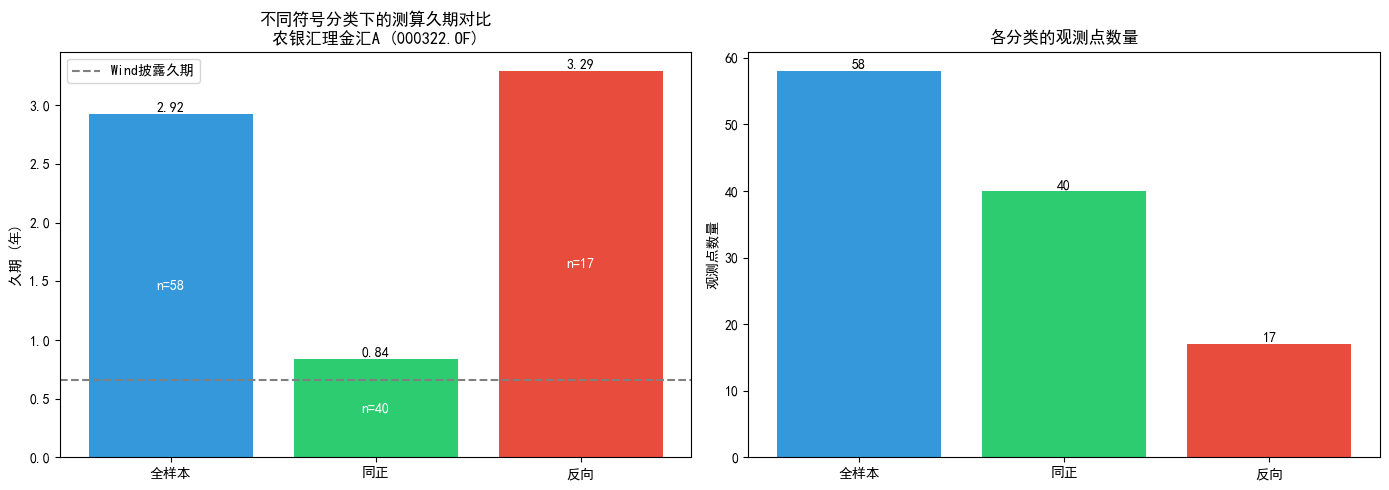


偏差分析 (测算 - Wind披露):
  全样本     : +2.264 年
  同正      : +0.184 年
  反向      : +2.633 年


In [21]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False    # 负号显示

if result:
    categories = ['全样本', '同正', '同负', '反向']
    durations = [
        result['full_sample']['duration'],
        result['same_positive']['duration'],
        result['same_negative']['duration'],
        result['opposite']['duration']
    ]
    counts = [
        result['full_sample']['count'],
        result['same_positive']['count'],
        result['same_negative']['count'],
        result['opposite']['count']
    ]

    # 过滤None值
    valid_data = [(c, d, n) for c, d, n in zip(categories, durations, counts) if d is not None]
    if valid_data:
        categories, durations, counts = zip(*valid_data)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # 久期对比
        bars = ax1.bar(range(len(categories)), durations, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
        ax1.set_xticks(range(len(categories)))
        ax1.set_xticklabels(categories)
        ax1.set_ylabel('久期 (年)')
        ax1.set_title(f'不同符号分类下的测算久期对比\n{test_fund_info["Name"]} ({test_fund_code})')

        # 添加Wind披露久期参考线
        if result['reported_duration']:
            ax1.axhline(y=result['reported_duration'], color='gray', linestyle='--', label='Wind披露久期')
            ax1.legend()

        # 在柱子上显示数值
        for i, (bar, dur, count) in enumerate(zip(bars, durations, counts)):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{dur:.2f}',
                    ha='center', va='bottom')
            ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                    f'n={count}',
                    ha='center', va='center', color='white', fontweight='bold')

        # 观测点数量
        ax2.bar(range(len(categories)), counts, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
        ax2.set_xticks(range(len(categories)))
        ax2.set_xticklabels(categories)
        ax2.set_ylabel('观测点数量')
        ax2.set_title('各分类的观测点数量')

        for i, (bar, count) in enumerate(zip(ax2.patches, counts)):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}',
                    ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # 打印偏差分析
        if result['reported_duration']:
            print("\n偏差分析 (测算 - Wind披露):")
            for cat in ['full_sample', 'same_positive', 'same_negative', 'opposite']:
                bias = result['bias_to_reported'].get(cat)
                if bias is not None:
                    cat_name = {'full_sample': '全样本', 'same_positive': '同正',
                              'same_negative': '同负', 'opposite': '反向'}[cat]
                    print(f"  {cat_name:8s}: {bias:+6.3f} 年")

## 6. 批量分析

对基金池进行批量符号分类久期分析

In [22]:
# 设置批量分析参数
BATCH_MAX_FUNDS = None  # 设置为数字限制分析基金数量，None表示分析全部
OUTPUT_FILE = f'./output/符号分类久期分析_{target_date.replace("-", "")}.xlsx'

print(f"开始批量分析...")
print(f"目标日期: {target_date}")
print(f"最大基金数: {BATCH_MAX_FUNDS or '全部'}")
print(f"输出文件: {OUTPUT_FILE}")

# 执行批量分析
batch_results = sign_analyzer.batch_analyze(
    fund_pool=preprocessor.get_fund_pool(target_date),
    target_date=target_date,
    calculator=calculator,
    max_funds=BATCH_MAX_FUNDS,
    output_file=OUTPUT_FILE,
    verbose=True
)

开始批量分析...
目标日期: 2024-12-31
最大基金数: 全部
输出文件: ./output/符号分类久期分析_20241231.xlsx
进度: 10/全部 | 成功: 9
[警告] 002301.OF 2024-12-31 回归自变量只有1个指数 CBA01851.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 002650.OF 2024-12-31 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 002864.OF 2024-12-31 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 002920.OF 2024-12-31 回归自变量只有1个指数 CBA01861.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 003002.OF 2024-12-31 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
进度: 20/全部 | 成功: 19
[警告] 004907.OF 2024-12-31 回归自变量只有1个指数 CBA01861.CS，且该指数已是最近久期匹配，无额外因子可补充
进度: 30/全部 | 成功: 29
[警告] 004981.OF 2024-12-31 回归自变量只有1个指数 CBA01861.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 005350.OF 2024-12-31 回归自变量只有1个指数 CBA02821.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 005725.OF 2024-12-31 回归自变量只有1个指数 CBA01861.CS，且该指数已是最近久期匹配，无额外因子可补充
进度: 40/全部 | 成功: 39
[警告] 006387.OF 2024-12-31 回归自变量只有1个指数 CBA01851.CS，且该指数已是最近久期匹配，无额外因子可补充
进度: 50/全部 | 成功: 49
[警告] 006545.OF 2024-12-31 回归自变量只有1个指数 CBA01861.CS，且该指数已是最近久期匹配，无额外因子可补充
[警告] 006609.OF 2024-12-31 回归自变量只有1个指数 C

## 7. 批量结果统计

In [23]:
if batch_results is not None and not batch_results.empty:
    print(f"\n批量分析完成！")
    print(f"成功分析 {len(batch_results)} 只基金")
    print(f"\n各符号分类的观测点统计:")
    for col in ['same_positive_count', 'same_negative_count', 'opposite_count']:
        print(f"  {col}: {batch_results[col].mean():.1f} (平均), {batch_results[col].median():.0f} (中位数)")

    # 只统计有Wind披露久期的基金
    with_reported = batch_results[batch_results['reported_duration'].notna()]
    print(f"\n有Wind披露久期的基金: {len(with_reported)} 只")

    # 偏差统计
    print(f"\n偏差统计 (测算 - Wind披露):")
    for cat in ['full_sample', 'same_positive', 'same_negative', 'opposite']:
        bias_col = f'{cat}_bias'
        if bias_col in batch_results.columns:
            bias_data = batch_results[bias_col].dropna()
            if len(bias_data) > 0:
                cat_name = {'full_sample': '全样本', 'same_positive': '同正',
                          'same_negative': '同负', 'opposite': '反向'}[cat]
                print(f"  {cat_name:8s}: 平均偏差 {bias_data.mean():+.3f} 年, "
                      f"中位数 {bias_data.median():+.3f} 年, "
                      f"标准差 {bias_data.std():.3f} 年")

    # 显示前10行
    print(f"\n前10行结果预览:")
    display_cols = ['fund_code', 'fund_name', 'reported_duration', 'full_sample_duration',
                   'same_positive_duration', 'same_negative_duration', 'opposite_duration']
    print(batch_results[display_cols].head(10).to_string())
else:
    print("批量分析未返回结果")


批量分析完成！
成功分析 1422 只基金

各符号分类的观测点统计:
  same_positive_count: 41.1 (平均), 40 (中位数)
  same_negative_count: 4.6 (平均), 5 (中位数)
  opposite_count: 12.1 (平均), 12 (中位数)

有Wind披露久期的基金: 1421 只

偏差统计 (测算 - Wind披露):
  全样本     : 平均偏差 -0.873 年, 中位数 -0.522 年, 标准差 2.015 年
  同正      : 平均偏差 -1.143 年, 中位数 -0.705 年, 标准差 2.074 年
  同负      : 平均偏差 -0.655 年, 中位数 -1.040 年, 标准差 4.190 年
  反向      : 平均偏差 -1.481 年, 中位数 -1.065 年, 标准差 2.772 年

前10行结果预览:
   fund_code     fund_name  reported_duration  full_sample_duration  same_positive_duration  same_negative_duration  opposite_duration
0  000084.OF         博时安盈A           1.123112              0.520380                0.345106                     NaN            0.08292
1  000089.OF   民生加银高等级信用债C           0.354515              0.349275                0.358465                     NaN            0.52038
2  000128.OF       大成景安短融A           0.195924              0.369600                0.398884                     NaN            0.08292
3  000322.OF       农银汇理金汇A         

## 8. 批量结果可视化

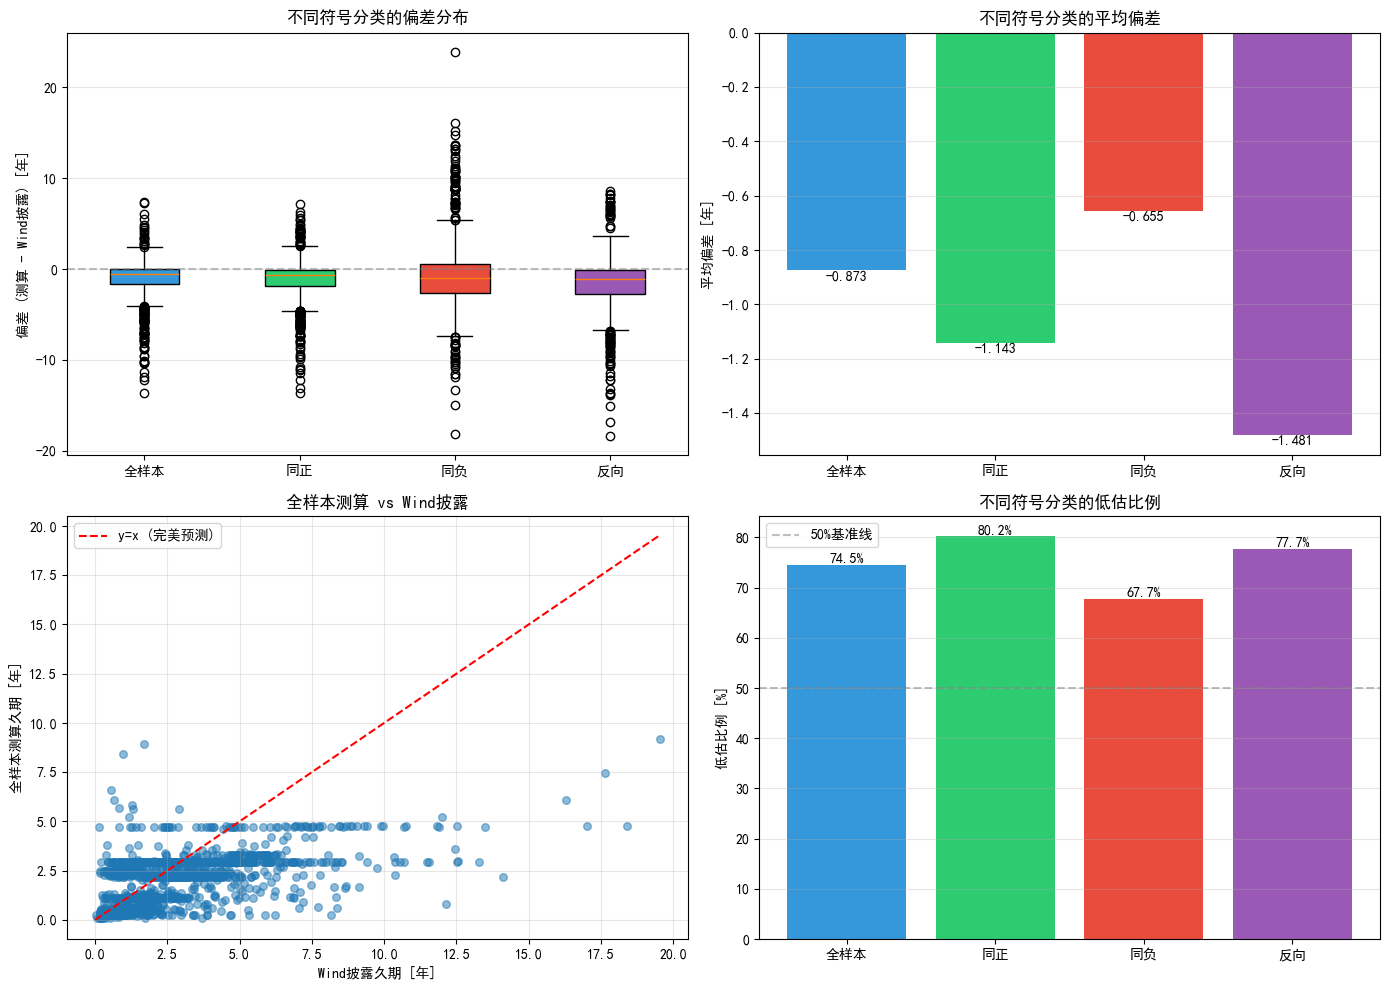

In [24]:
if batch_results is not None and not batch_results.empty:
    # 只统计有Wind披露久期的基金
    with_reported = batch_results[batch_results['reported_duration'].notna()]

    if len(with_reported) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. 偏差箱线图
        bias_data = []
        bias_labels = []
        for cat in ['full_sample', 'same_positive', 'same_negative', 'opposite']:
            bias_col = f'{cat}_bias'
            if bias_col in with_reported.columns:
                data = with_reported[bias_col].dropna()
                if len(data) > 0:
                    bias_data.append(data)
                    bias_labels.append({'full_sample': '全样本', 'same_positive': '同正',
                                       'same_negative': '同负', 'opposite': '反向'}[cat])

        if bias_data:
            ax = axes[0, 0]
            bp = ax.boxplot(bias_data, labels=bias_labels, patch_artist=True)
            for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']):
                patch.set_facecolor(color)
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax.set_ylabel('偏差 (测算 - Wind披露) [年]')
            ax.set_title('不同符号分类的偏差分布')
            ax.grid(axis='y', alpha=0.3)

        # 2. 偏差均值柱状图
        ax = axes[0, 1]
        bias_means = [d.mean() for d in bias_data]
        bars = ax.bar(range(len(bias_labels)), bias_means,
                     color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax.set_xticks(range(len(bias_labels)))
        ax.set_xticklabels(bias_labels)
        ax.set_ylabel('平均偏差 [年]')
        ax.set_title('不同符号分类的平均偏差')
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, bias_means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top')

        # 3. 测算久期 vs Wind披露久期散点图 (全样本)
        ax = axes[1, 0]
        valid_data = with_reported[with_reported['full_sample_duration'].notna()]
        if len(valid_data) > 0:
            ax.scatter(valid_data['reported_duration'], valid_data['full_sample_duration'],
                      alpha=0.5, s=30)
            max_val = max(valid_data['reported_duration'].max(),
                         valid_data['full_sample_duration'].max())
            ax.plot([0, max_val], [0, max_val], 'r--', label='y=x (完美预测)')
            ax.set_xlabel('Wind披露久期 [年]')
            ax.set_ylabel('全样本测算久期 [年]')
            ax.set_title('全样本测算 vs Wind披露')
            ax.legend()
            ax.grid(alpha=0.3)

        # 4. 各分类偏差对比（只统计有三种分类数据的基金）
        ax = axes[1, 1]
        # 统计各分类偏差为负（低估）的比例
        under_estimate_ratios = []
        for i, (cat, data) in enumerate(zip(['full_sample', 'same_positive', 'same_negative', 'opposite'], bias_data)):
            under_estimate = (data < 0).sum() / len(data)
            under_estimate_ratios.append(under_estimate * 100)

        bars = ax.bar(range(len(bias_labels)), under_estimate_ratios,
                     color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
        ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50%基准线')
        ax.set_xticks(range(len(bias_labels)))
        ax.set_xticklabels(bias_labels)
        ax.set_ylabel('低估比例 [%]')
        ax.set_title('不同符号分类的低估比例')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, under_estimate_ratios):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.1f}%', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()